In [111]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Loading the txt file

In [112]:
f = open("WhatsApp Chat with Research paper.txt", 'r', encoding='utf-8')

In [113]:
data = f.read()

In [114]:
print(type(data))

<class 'str'>


In [115]:
print(data)

09/04/2026, 5:35 pm - Messages and calls are end-to-end encrypted. Only people in this chat can read, listen to, or share them. *Learn more*
09/04/2026, 5:35 pm - Girish created group "Research paper"
09/04/2026, 5:35 pm - Girish added you
09/04/2026, 5:38 pm - Girish: sabbei ko college email deuna
09/04/2026, 5:38 pm - Girish: @⁨all⁩
09/04/2026, 5:38 pm - @Mrpramez: Np05cp4a250002@iic.edu.np
09/04/2026, 5:40 pm - Girish: Comparative analysis of AI-generated code vs student-written code in efficiency and correctness
09/04/2026, 5:41 pm - Girish: kastoo cha
09/04/2026, 5:41 pm - Girish: yo
09/04/2026, 6:02 pm - @Mrpramez: Good topic
09/04/2026, 6:07 pm - Girish: aaejeii ramroo khojam naa
09/04/2026, 6:46 pm - Panda Thapaliya: np05cp4a250016@iic.edu.np
10/04/2026, 9:15 am - @Mrpramez: Topic - Detecting dark patterns in web UI using machine learning

Question - can a DOM based classifier reliably detect the top 5 most common dark patterns on e-commerce websites? <This message was edited>


Data filtering

In [116]:
date_pattern = r"\d{1,2}/\d{1,2}/\d{2,4},\s\d{1,2}:\d{2}(?:\s*[\u202f ]?(?:am|pm|AM|PM))?"
entry_pattern = (
    r"(?s)^("
    + date_pattern +
    r")\s-\s(.*?)"
    r"(?=\n" + date_pattern + r"\s-\s|\Z)"
)

In [117]:
entries = re.findall(entry_pattern, data, flags=re.M)
messages = [msg for _, msg in entries]
messages[:5]


['Messages and calls are end-to-end encrypted. Only people in this chat can read, listen to, or share them. *Learn more*',
 'Girish created group "Research paper"',
 'Girish added you',
 'Girish: sabbei ko college email deuna',
 'Girish: @\u2068all\u2069']

In [118]:
dates = [
    re.sub(r"\s*(?:am|pm|AM|PM)$", "", d.replace("\u202f", " "))
    for d, _ in entries
]
dates[:5]

['09/04/2026, 5:35',
 '09/04/2026, 5:35',
 '09/04/2026, 5:35',
 '09/04/2026, 5:38',
 '09/04/2026, 5:38']

Creating a dataframe

In [119]:
df = pd.DataFrame({"message": messages, "date": dates})

df["date"] = pd.to_datetime(
        df["date"],
        format="mixed",
        dayfirst=True
    )

In [120]:
df.head()

,message,date
0,Messages and calls are end-to-end encrypted. O...,2026-04-09 05:35:00
1,"Girish created group ""Research paper""",2026-04-09 05:35:00
2,Girish added you,2026-04-09 05:35:00
3,Girish: sabbei ko college email deuna,2026-04-09 05:38:00
4,Girish: @⁨all⁩,2026-04-09 05:38:00


In [121]:
df.shape

(181, 2)

Seperate users and messages

In [122]:
users = []
messages = []

for message in df["message"]:

    # Normal message:- sender: message
    match = re.match(r"^([^:]+):\s(.*)$", message, flags=re.S)

    if match:
        users.append(match.group(1))
        messages.append(match.group(2))

    # Group notification
    else:
        users.append("group_notification")
        messages.append(message)

df["user"] = users
df["message"] = messages            

In [123]:
df.head()

,message,date,user
0,Messages and calls are end-to-end encrypted. O...,2026-04-09 05:35:00,group_notification
1,"Girish created group ""Research paper""",2026-04-09 05:35:00,group_notification
2,Girish added you,2026-04-09 05:35:00,group_notification
3,sabbei ko college email deuna,2026-04-09 05:38:00,Girish
4,@⁨all⁩,2026-04-09 05:38:00,Girish


Extracting year, month, date and time 

In [124]:
df['year']= df['date'].dt.year

In [125]:
df['month'] =df['date'].dt.month_name()

In [126]:
df['day'] = df['date'].dt.day

In [127]:
df['hour'] = df['date'].dt.hour

In [128]:
df['minute'] = df['date'].dt.minute

In [129]:
df.head()

,message,date,user,year,month,day,hour,minute
0,Messages and calls are end-to-end encrypted. O...,2026-04-09 05:35:00,group_notification,2026,April,9,5,35
1,"Girish created group ""Research paper""",2026-04-09 05:35:00,group_notification,2026,April,9,5,35
2,Girish added you,2026-04-09 05:35:00,group_notification,2026,April,9,5,35
3,sabbei ko college email deuna,2026-04-09 05:38:00,Girish,2026,April,9,5,38
4,@⁨all⁩,2026-04-09 05:38:00,Girish,2026,April,9,5,38


Number of messages

In [130]:
# Gives total number of messages in the whole group
df['user'].shape[0]

181

In [131]:
df['user'].unique()

<ArrowStringArray>
['group_notification',             'Girish',          '@Mrpramez',
    'Panda Thapaliya',        'GauravDulal',      'Praful Dhakal']
Length: 6, dtype: str

In [132]:
#This gives the number of messages sent by a single user
df[df['user'] == "Praful Dhakal"].shape[0]

3

Number of Words

In [133]:
words = []
for message in df['message']:
    words.extend(message.split())

In [134]:
len(words)

2884

Number of links

In [135]:
# Finds urls from the given string
from urlextract import URLExtract

In [136]:
extractor = URLExtract()
urls = extractor.find_urls("https://github.com/gyr0byte/OOP_Purity_Analyzer.git")
urls

['https://github.com/gyr0byte/OOP_Purity_Analyzer.git']

In [137]:
link = []
for message in df['message']:
    link.extend(extractor.find_urls(message))

In [138]:
link

['https://www.overleaf.com/7124766772tmgrsrjxqhbs#461871',
 'https://www.overleaf.com/7124766772tmgrsrjxqhbs#461871',
 'https://github.com/gyr0byte/OOP_Purity_Analyzer.git',
 'https://oop-purity-analyzer-1.onrender.com',
 'https://www.youtube.com/watch?v=eF7HoC-cLRM&list=PLaldQ9PzZd9qPYGj4aWUXitBlfWz72e9m&index=27']

In [139]:
len(link)

5

Most active users

In [140]:
df.head()

,message,date,user,year,month,day,hour,minute
0,Messages and calls are end-to-end encrypted. O...,2026-04-09 05:35:00,group_notification,2026,April,9,5,35
1,"Girish created group ""Research paper""",2026-04-09 05:35:00,group_notification,2026,April,9,5,35
2,Girish added you,2026-04-09 05:35:00,group_notification,2026,April,9,5,35
3,sabbei ko college email deuna,2026-04-09 05:38:00,Girish,2026,April,9,5,38
4,@⁨all⁩,2026-04-09 05:38:00,Girish,2026,April,9,5,38


In [141]:
x = df['user'].value_counts()

In [142]:
name = x.index
count = x.values

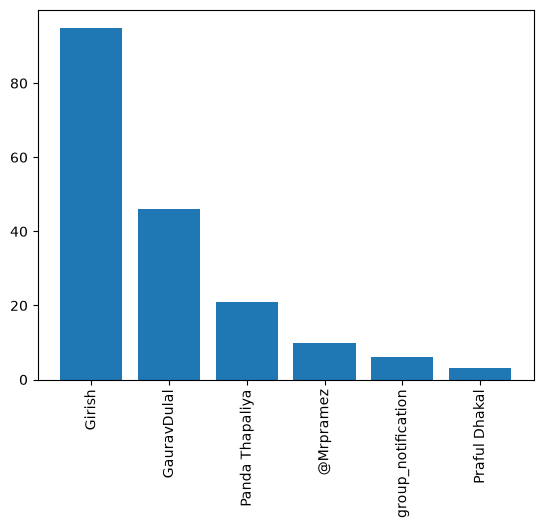

In [143]:
plt.bar(name, count)
plt.xticks(rotation = 'vertical')
plt.show()

Active user by percentage of messages

In [144]:
round((df['user'].value_counts()/df.shape[0])*100 , 2).reset_index().rename(columns = {'index': 'name', 'count': 'percent'})

,user,percent
0,Girish,52.49
1,GauravDulal,25.41
2,Panda Thapaliya,11.60
3,@Mrpramez,5.52
4,group_notification,3.31
5,Praful Dhakal,1.66


Most frequent words in chat

- For only keeping the essential and words with actual value.
    - remove group notification
    - remove media omitted message

In [145]:
temp = df[df['user']!= 'group_notification']
temp = temp[temp['message'] != "<Media omitted>"]
temp        #has only the data that are not group notification and media files

,message,date,user,year,month,day,hour,minute
3,sabbei ko college email deuna,2026-04-09 05:38:00,Girish,2026,April,9,5,38
4,@⁨all⁩,2026-04-09 05:38:00,Girish,2026,April,9,5,38
5,Np05cp4a250002@iic.edu.np,2026-04-09 05:38:00,@Mrpramez,2026,April,9,5,38
6,Comparative analysis of AI-generated code vs s...,2026-04-09 05:40:00,Girish,2026,April,9,5,40
7,kastoo cha,2026-04-09 05:41:00,Girish,2026,April,9,5,41
...,...,...,...,...,...,...,...,...
174,https://oop-purity-analyzer-1.onrender.com,2026-06-04 11:24:00,GauravDulal,2026,June,4,11,24
175,https://www.youtube.com/watch?v=eF7HoC-cLRM&li...,2026-06-16 10:07:00,GauravDulal,2026,June,16,10,7
177,Yo,2026-08-01 10:29:00,Panda Thapaliya,2026,August,1,10,29
178,Kaila dhaki start garna ho,2026-08-01 10:29:00,Panda Thapaliya,2026,August,1,10,29


In [146]:
f = open("stopwords.txt", 'r')
stop_words = f.read()
print(stop_words)

!
@
#
$
%
^
&
*
(
)
_
-
+
a
about
above
across
after
again
against
all
almost
alone
along
already
also
although
always
among
an
and
another
any
anybody
anyone
anything
anywhere
are
area
areas
around
as
ask
asked
asking
asks
at
away
b
back
backed
backing
backs
be
became
because
become
becomes
been
before
began
behind
being
beings
best
better
between
big
both
but
by
c
came
can
cannot
case
cases
certain
certainly
clear
clearly
come
could
d
did
differ
different
differently
do
does
done
down
down
downed
downing
downs
during
e
each
early
either
end
ended
ending
ends
enough
even
evenly
ever
every
everybody
everyone
everything
everywhere
f
face
faces
fact
facts
far
felt
few
find
finds
first
for
four
from
full
fully
further
furthered
furthering
furthers
g
gave
general
generally
get
gets
give
given
gives
go
going
good
goods
got
great
greater
greatest
group
grouped
grouping
groups
h
had
has
have
having
he
her
here
herself
high
high
high
higher
highest
him
himself
his
how
however
i
if
important
in

In [147]:
words = []

for message in temp['message']:
    for word in message.lower().split():
        if word not in stop_words:
            words.append(word)

In [148]:
from collections import Counter

In [149]:
count = pd.DataFrame(Counter(words).most_common(25))
count.rename(columns={0: "Word", 1: "Frequency"}, inplace=True)

count

,Word,Frequency
0,—,52
1,→,30
2,purity,24
3,oop,21
4,---,18
5,framework,17
6,languages,16
7,research,16
8,metrics,16
9,language,15


Emoji Analysis

In [150]:
import emoji

In [151]:
emojis = []
for message in df['message']:
    emojis.extend([c for c in message if c in emoji.EMOJI_DATA])

In [161]:
emoji_counts = Counter(emojis).most_common(len(Counter(emojis)))
emoji_counts

[('😮', 1), ('💨', 1), ('👏', 1), ('👍', 1), ('🫡', 1)]

In [162]:
pd.DataFrame(emoji_counts)

,0,1
0,😮,1
1,💨,1
2,👏,1
3,👍,1
4,🫡,1


Month based analysis

In [153]:
df['month_num'] = df['date'].dt.month

In [154]:
df.head()

,message,date,user,year,month,day,hour,minute,month_num
0,Messages and calls are end-to-end encrypted. O...,2026-04-09 05:35:00,group_notification,2026,April,9,5,35,4
1,"Girish created group ""Research paper""",2026-04-09 05:35:00,group_notification,2026,April,9,5,35,4
2,Girish added you,2026-04-09 05:35:00,group_notification,2026,April,9,5,35,4
3,sabbei ko college email deuna,2026-04-09 05:38:00,Girish,2026,April,9,5,38,4
4,@⁨all⁩,2026-04-09 05:38:00,Girish,2026,April,9,5,38,4


In [155]:
timeline = df.groupby(['year', 'month']).count()['message'].reset_index()
timeline

,year,month,message
0,2026,April,64
1,2026,August,4
2,2026,July,1
3,2026,June,51
4,2026,May,61


In [156]:
# A column with both month and date for plotting in graph
time = []
for i in range(timeline.shape[0]):
    time.append(timeline['month'][i] + '-' + str(timeline['year'][i]))

In [157]:
time

['April-2026', 'August-2026', 'July-2026', 'June-2026', 'May-2026']

In [158]:
timeline['time'] = time

In [159]:
timeline

,year,month,message,time
0,2026,April,64,April-2026
1,2026,August,4,August-2026
2,2026,July,1,July-2026
3,2026,June,51,June-2026
4,2026,May,61,May-2026


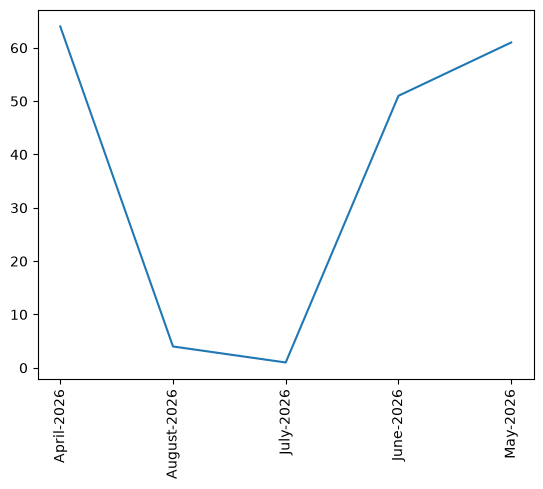

In [160]:
plt.plot(timeline['time'], timeline['message'])
plt.xticks(rotation = 'vertical')
plt.show()